# Installing and using pysmurf on your own machine

pysmurf is a public github repo and can be downloaded here - <a href="https://github.com/slaclab/pysmurf">https://github.com/slaclab/pysmurf</a>.

pysmurf requires python3 package.  Installing python3 in Linux is straightforward (if it's not on your machine already).  I'm writing this on a Windows laptop where I have python3 installed via anaconda3 - I have the Python3.6 version installed from here - <a href="https://www.anaconda.com/distribution/#download-section">https://www.anaconda.com/distribution/#download-section</a>. We will be requiring Python 3.7 soon. 

To install pysmurf, you can clone the repository and install with pip using the following commands:

Documentation is built using Sphinx, and follows the Google Style Docstrings. To build the documentation first install the pysmurf package, then run:

Output will be located in _build/html. You can view the compiled documentation by opening _build/html/index.html in the browser of your choice.

Go ahead and import pysmurf & make sure it is in your PYTHONPATH

In [6]:
import pysmurf.client
print(pysmurf)

<module 'pysmurf' from '/usr/local/src/pysmurf/python/pysmurf/__init__.py'>


If you're not on a SMuRF server, you'll need to instatiate pysmurf with a flag telling it not to try and talk to the EPICs server (and other things). You'll also need to tell it where the cfg file the data was taken with is (as of right now - we need a better strategy for this). Here's stupid way to find the path to your pysmurf's config file directory:

In [7]:
from sodetlib.det_config import DetConfig

cfg = DetConfig()
cfg.parse_args(args=[])
S = cfg.get_smurf_control(offline=True)

[ 2020-06-05 23:08:05 ]  Offline mode


# SMuRF example data in this tutorial

This tutorial has some SMuRF data in it for you to try loading on your own machine offline.  That data is in the smurf_tutorials/example_data directory (not in git).

In [8]:
!ls example_data

1589308794_tune.npy


# SMuRF data

This tutorial shows how to open and interpret a lot of the most common data structures and files that get saved in routine SMuRF operation.  Almost all data is timestamped with the ctime at which the data was taken.  You can get the current ctime through SMuRF like this; 

## Tune data 

Load tune data.

In [9]:
S.load_tune('./example_data/1589308794_tune.npy')

[ 2020-06-05 23:08:05 ]  filename explicitly given. Overriding last_tune bool in load_tune.
[ 2020-06-05 23:08:05 ]  Done loading tuning
[ 2020-06-05 23:08:05 ]  Loading tune data for all bands=[0, 1, 2, 3].


Tune data is now loaded into pysmurf.  Keep in mind the tune data is just a numpy npy file, so you don't have to load it using pysmurf.  Let's look at what's in the tune files.  Loading the tune file populates a dictionary in pysmurf named freq_resp.  It's a nested dictionary.  The keys of freq_resp are the bands for which tune data exists in the file - in this case, that's bands 2 & 3, or 5-5.5GHz and 5.5-6GHz:

In [10]:
S.freq_resp.keys()

dict_keys([0, 1, 2, 3])

Each band dictionary has the following keys (descending into band 2, for example):

In [11]:
S.freq_resp[3].keys()

dict_keys(['lock_status', 'find_freq', 'drive', 'resonances'])

<code>lock_status</code> is a dictionary populated by the pysmurf <code>check_lock</code> routine, which checks if channels are tracking well.  It wasn't run for this dataset, so there's no information available on this here:

In [12]:
S.freq_resp[3]['lock_status']

{}

<code>drive</code> is the tone power (the amplitudeScale fw variable) at which the tune data was taken with.  In this case, 11:

In [13]:
S.freq_resp[3]['drive']

12

For the hardware this tune was taken with, 12 corresponds to about -26dBm per tone at the SMuRF RF output, and approximately -70dBm per tone into the resonators.  Those power levels are close to optimal for most existing uMUX resonator chips.  Each unit of amplitudeScale corresponds to an increment or decrement of 3dB.  

<code>find_freq</code> is populated by the pysmurf <code>find_freq</code> routine, which slowly sweeps a tone over the entire band frequency range, using it to measure the complex transmission as a function of frequency.  It contains the following keys:

In [14]:
S.freq_resp[3]['find_freq'].keys()

dict_keys(['subband', 'f', 'resp', 'timestamp', 'resonance'])

This tune file doesn't actually have the <code>find_freq</code> data - <code>f</code> and </resp> are all zeros.  But it does have a record of the resonance frequencies found from a previous <code>find_freq</code> dataset that must have been loaded for this tune : 

In [15]:
import numpy as np
np.set_printoptions(threshold=10)
resonance=S.freq_resp[3]['find_freq']['resonance']
print(resonance)

[-241.24000959 -239.80000953 -238.9600095  ... -102.48000407 -100.24000398
  134.40000534]


These are in MHz, and w.r.t. the band center.  Since this is band 3, that means the resonator frequency found at the first element, -241.1 MHz, was at 5.509 GHz (=5.75GHz - 241.1 MHz).

Last, the <code>resonances</code> in the <code>find_freq</code> dictionary contains the results from the pysmurf <code>setup_notches</code> algorithm - the results of a fine scan of transmission vs frequency for each resonator candidate found by the <code>find_freq</code> routine, and the tracking algorithm inputs computed from that data.  We sometimes colloquially call these results "etaScans."  This is the critical information that pysmurf needs to hand off to the fw to configure each readout channel for tracking.  The keys of the <code>resonances</code> dictionary are the resonator indices.  Let's look at the first.

In [16]:
S.freq_resp[3]['resonances'][0]

{'freq': 5508.737990413983,
 'eta': (1.812844621197872-1.5900553844199699j),
 'eta_scaled': 0.502367713551446,
 'eta_phase': -41.25416809872018,
 'r2': 1,
 'eta_mag': 2.411365120865978,
 'latency': 0,
 'Q': 1,
 'freq_eta_scan': array([5508.45999041, 5508.46199041, 5508.46399041, ..., 5509.05599041,
        5509.05799041, 5509.05999041]),
 'resp_eta_scan': array([0.05126488-0.07749879j, 0.05121684-0.07749879j,
        0.05123544-0.07763815j, ..., 0.06831503-0.05703425j,
        0.06826234-0.05717385j, 0.0682044 -0.05729544j]),
 'subband': 13,
 'channel': 57,
 'offset': -1.2620000492734107}

Here's a quick summary of each of these variables:<br>

<code>freq</code>: the refined resonator frequency determined from the eta scan.<br>
<code>eta</code>: the computed eta.<br>
<code>eta_scaled</code>: the computed scaled eta (proportional to abs(eta), needed by fw).<br>
<code>eta_phase</code>: the complex eta phase.<br>
<code>r2</code>: not currently useful, always 1.<br>
<code>eta_mag</code>: the magnitude of eta.<br>
<code>latency</code>: not currently useful, always 0.<br>
<code>Q</code>: not currently useful, always 1.<br>
<code>freq_eta_scan</code>: the frequencies scanned in the etaScan, in MHz.<br>
<code>resp_eta_scan</code>: the complex response measured at each frequency, units arbitrary.<br>
<code>subband</code>: the subband this resonator was scanned in.<br>
<code>channel</code>: the channel assigned to this resonator for readout.<br>
<code>offset</code>: the offset of freq from the center of this resonators' subband.<br>

From this data, you can plot the complex transmission close in on every resonator that was assigned to a readout channel by this tune.  For instance, for the first channel in this dataset:

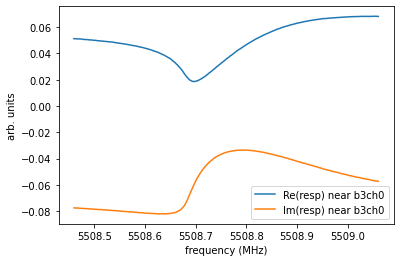

In [17]:
import matplotlib.pylab as plt
import numpy as np
%matplotlib inline

band=3
chIdx=0
etaScan=S.freq_resp[band]['resonances'][chIdx]
freq_eta_scan=etaScan['freq_eta_scan']
resp_eta_scan=etaScan['resp_eta_scan']

plt.plot(freq_eta_scan,np.real(resp_eta_scan),label='Re(resp) near b%dch%d'%(band,chIdx))
plt.plot(freq_eta_scan,np.imag(resp_eta_scan),label='Im(resp) near b%dch%d'%(band,chIdx))
plt.ylabel('arb. units')
plt.xlabel('frequency (MHz)')
plt.legend()
plt.show()

In total, this tune file contains etaScans over

In [18]:
nChannels=0
bands=[3]
for band in bands:
    nChannelsInThisBand=len(S.freq_resp[band]['resonances'].keys())
    print('Channels etaScanned in band %d = %d'%(band,nChannelsInThisBand))
    nChannels+=nChannelsInThisBand
print('-------------')
print('Channels etaScanned in bands %s = %d'%(str(bands),nChannels))

Channels etaScanned in band 3 = 48
-------------
Channels etaScanned in bands [3] = 48


But this is before any quality cuts.  The <code>find_freq</code> algorithm that finds resonator candidates for the etaScans is purposely over-permissive.  Of these 454, 410 or so of them end up tracking well.  If you look through the etaScan results for all of these channels, you'll likely be able to spot all or nearly all of the channels that either 1) aren't real resonators but fooled the <code>find_freq</code> routine or 2) don't track well despite being actual resonators.

### How the data was taken

On smurf-srv04.  For this example, I have 410 resonators locked and tracking all together on bands 2 and 3.  Taking a 60 second time stream:

In [24]:
# Load pysmurf
import pysmurf

# Initialize a pysmurf instance connected to the EPICs server named 'test_epics'.  
# Do not run setup (assumes setup was run before this script).  Also assumes you're 
# fully tuned.
S = pysmurf.SmurfControl(make_logfile=False, setup=False, epics_root='test_epics', \
                         cfg_file='/usr/local/controls/Applications/smurf/pysmurf/pysmurf/cfg_files/experiment_fp28_smurfsrv04.cfg')

# Stream data to file for 60 seconds
datadir = S.take_stream_data(meas_time=60)

AttributeError: module 'pysmurf' has no attribute 'SmurfControl'

After initializing a pysmurf instance, we streamed data to file for 60 seconds.  This generated three files in /data/smurf_data/20190130/1548916176/outputs/; 

In [27]:
ls /data/smurf_data/20190130/1548916176/outputs/1548916177

ls: cannot access '/data/smurf_data/20190130/1548916176/outputs/1548916177': No such file or directory


The .yml file is a record of every PyROGUE register value just before the data was taken.  This allows the configuration of different datasets to be compared register by register:

In [26]:
!head -n 200 /data/smurf_data/20190130/1548916176/outputs/1548916177.yml


head: cannot open '/data/smurf_data/20190130/1548916176/outputs/1548916177.yml' for reading: No such file or directory


Unsurprisingly, it's a ton of info.  Just showing the first 200 lines above.

The *_mask.txt file is a record of which SMuRF channels were assigned to what array indices in the SMuRF .dat file.

In [ ]:
!nl -v0 /data/smurf_data/20190130/1548916176/outputs/1548916177_mask.txt

Here I've just printed the contents of the mask file with a line number, indexed from zero.  For the existing SMuRF stream transmitter, we can only write 512 channels to file simultaneously.  Each SMuRF 500 MHz band has 512 "CryoChannel" instances, each of which can be configured to track a resonator (otherwise it's just not used).  This mask file encodes the mapping from those channels onto the 512 we're able to save (right now - this will be expanded for SO).  The actual master mask used by the data writer lives somewhere else, but a copy is saved with each dataset so that the mapping is not lost when/if the master changes.  The master mask file lives in the transmitter directory here - /usr/local/controls/Applications/smurf/smurf2mce/master/mcetransmit/mask.txt.  pysmurf knows how to modify it as needed to write the channels you have configured to file - but you have to have a copy of the mask to figure out how to back out which channel ended up at what index in the array saved on disk.

Lastly, the .dat file is data.

### Loading and plotting timestream data

Now we will load the data. The data and mask are assumed to have the same file name, so we will only pass it the datafile. It returns time, data, and the mask.  I'm running this example using SMuRF on my personal machine on the example data directory in these tutorials (see section above for how to unpack the data so you can load it here):

In [ ]:
t, dat, mask = S.read_stream_data('example_data\\1548916176\\outputs\\1548916177.dat')

The mask is shape (n_band, n_channel) and is -1 for all unassigned channels and is the array index for the assigned channels. So if mask[2,15] = 4, then band 2 channel 15 is the 4th element (0 indexed) in the datafile.

In [ ]:
import numpy as np
np.shape(mask)

In [ ]:
band, channel = np.where(mask != -1)
print(band)
print(channel)

Let us arbitrarily choose a channel and plot it.

In [ ]:
idx = 10
print('Band {} Ch {:03}'.format(band[idx], channel[idx]))
print(mask[band[idx],channel[idx]])

In [ ]:
import matplotlib.pyplot as plt
dat_ch=dat[mask[band[idx], channel[idx]]]
t_sec=(t-t[0])/1.e9
print('t[0]=%d'%(t[0]))
plt.plot(t_sec,dat_ch-np.mean(dat_ch))
plt.title('Band {} Ch {:03}'.format(band[idx], channel[idx]))
plt.ylabel('Phase ($\Phi_{0}$)')
plt.xlabel('Time (sec)')
plt.show()

The timestamp is in ns since Jan 1, 1970 (<a href="https://en.wikipedia.org/wiki/Unix_time">because it's awesome</a>) and the y axis is in units of the SQUID flux quantum.  To convert the units to equivalent TES current, just multiply by 

In [ ]:
print('%f pA/phi0'%(S.pA_per_phi0/(2.*np.pi)))

where pA_per_phi0 is in the config file that was loaded when pysmurf was instantiated.  pA_per_phi0 is a function of the coupling (mutual inductance) of the inductor inline with the TES to the SQUID.

This data was taken at ~180 Hz (set by the MCE syncbox rate).  Here's

In [ ]:
from scipy import signal
pA_ch=dat[mask[band[idx], channel[idx]]]*S.pA_per_phi0/(2.*np.pi)
f, Pxx = signal.welch(pA_ch, nperseg=2**13, fs=180, detrend='constant')
Axx = np.sqrt(Pxx)  # pA
plt.plot(f,Axx)

plt.title('Band {} Ch {:03}'.format(band[idx], channel[idx]))
plt.gca().set_xlabel('Freq [Hz]')
plt.gca().set_xlim(f[1],f[-1])
plt.gca().set_ylabel('Amp [pA/rtHz]')
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')

popt,pcov,f_fit,Pxx_fit = S.analyze_psd(f,Axx)
wl,n,f_knee = popt

plt.plot(f_fit,Pxx_fit,linestyle = '--',label=r'$n=%.2f$' % (n))
plt.plot(f_knee,2.*wl,linestyle = 'none',marker = 'o',label=r'$f_\mathrm{knee} = %.2f\,\mathrm{Hz}$' % (f_knee))
plt.plot(f_fit,wl + np.zeros(len(f_fit)),linestyle = ':',label=r'$\mathrm{wl} = %.0f\,\mathrm{pA}/\sqrt{\mathrm{Hz}}$' % (wl))
print('white noise level = %0.1f pA/rt.Hz'%(wl))

This channel doesn't have any TES on it - this is just SQUID+resonator noise (and dominated by resonator TLS noise).  The large spike on the right is 60Hz.

## Tracking setup data

In [ ]:
f, df, sync = S.decode_data('example_data\\1549243856\\outputs\\1549244377.dat')
npts=300
idx=2
plt.plot(f[:,idx][:npts]-np.mean(f[:,idx][:npts]))
plt.plot(df[:,idx][:npts]-np.mean(df[:,idx][:npts]))

## IV data 

In [ ]:
fn_iv_raw_data='example_data\\1549243856\\outputs\\1549244462_iv_raw_data.npy'
S.analyze_slow_iv_from_file(fn_iv_raw_data, make_plot=True,
            show_plot=True, save_plot=False)